# QA/QC calibration chains and station spectra — saved-coefficient workflow

This notebook loads the saved **temporal coefficients** and saved
**bidirectional spatial coefficients**, checks calibration-chain closure,
extracts station pixels, computes spectral summaries and NDVI740, and compares
raw and corrected imagery against field spectra.

The coefficient convention is always:

\[
\mathrm{destination} = \mathrm{gain}\times\mathrm{source}+\mathrm{offset}.
\]

## Closure paths

The May 4 closure compares:

- **Path A:** Westham May 18 → Westham May 4.
- **Path B — independent reverse:** Westham May 18 → Brunswick May 18 using
  the independently fitted Westham → Brunswick coefficients, followed by
  Brunswick May 18 → Brunswick May 4 → Westham May 4.
- **Path B — algebraic inverse:** the same path, except Westham May 18 →
  Brunswick May 18 is obtained by algebraically inverting the saved
  Brunswick → Westham transformation.

The independent reverse is a QA diagnostic. The algebraic inverse is included
because it is exactly reciprocal to the forward spatial transformation.

## 1. Imports and project configuration

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns

from IPython.display import display
from rasterio.features import geometry_mask, geometry_window
from rasterio.transform import xy
from shapely.geometry import mapping
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.style.use("default")
%config InlineBackend.figure_format = "retina"
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "data").exists()
            or (candidate / "src").exists()
        ):
            return candidate

    return start


PROJECT_ROOT = find_project_root()

STORAGE_ACCOUNT_NAME = "geoanalytics"
CONTAINER_NAME = "wesa-fup-restricted-027817p"
USE_AZURE_CONTAINER = True

if USE_AZURE_CONTAINER:
    try:
        import hatfield_funcs as hf

        hf.config.configure_azure()
        hf.config.configure_data_root_path(
            CONTAINER_NAME
        )

        os.environ.setdefault(
            "AZURE_STORAGE_ACCOUNT",
            STORAGE_ACCOUNT_NAME,
        )
        os.environ.setdefault(
            "GDAL_AZURE_USE_MSI",
            "YES",
        )
        os.environ.setdefault(
            "GDAL_CACHEMAX",
            "512",
        )

    except ImportError:
        warnings.warn(
            "hatfield_funcs is unavailable. Azure access "
            "must already be configured."
        )


def container_path(
    path,
    container_name=CONTAINER_NAME,
):
    normalized = (
        str(path)
        .replace("\\", "/")
        .lstrip("/")
    )

    if USE_AZURE_CONTAINER:
        return (
            f"/vsiaz/{container_name}/"
            f"{normalized}"
        )

    return str(PROJECT_ROOT / normalized)


print("Project root:", PROJECT_ROOT)

Project root: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm


## 2. Analysis configuration and band metadata

In [2]:
DATES = [
    "2026-05-04",
    "2026-05-18",
]

ROUNDS = [1, 2]

ROUND_DATES = {
    1: "2026-05-04",
    2: "2026-05-18",
}

DATE_TO_ROUND = {
    date: round_number
    for round_number, date
    in ROUND_DATES.items()
}

DLS_MODES = [
    "DLS",
    "NoDLS",
]

SITES = [
    "westham",
    "brunswick",
]

SOURCE_BAND_NUMBERS = list(range(1, 12))

SOURCE_BAND_NAMES = [
    "B1",
    "B2",
    "B3",
    "B4",
    "PAN",
    "B5",
    "B6",
    "B7",
    "B8",
    "B9",
    "B10",
]

SPECTRAL_WAVELENGTHS_NM = {
    "B1": 444,
    "B2": 475,
    "B3": 531,
    "B4": 560,
    "B5": 650,
    "B6": 668,
    "B7": 705,
    "B8": 717,
    "B9": 740,
    "B10": 842,
}

SPECTRAL_BAND_NAMES = list(
    SPECTRAL_WAVELENGTHS_NM
)

BAND_METADATA = pd.DataFrame({
    "source_band": SOURCE_BAND_NUMBERS,
    "band_name": SOURCE_BAND_NAMES,
})

BAND_METADATA["band_index"] = np.arange(
    len(BAND_METADATA)
)

BAND_METADATA["wavelength_nm"] = (
    BAND_METADATA["band_name"]
    .map(SPECTRAL_WAVELENGTHS_NM)
)

BAND_METADATA["is_pan"] = (
    BAND_METADATA["band_name"]
    .eq("PAN")
)

NDVI_RED_NM = 668
NDVI_NIR_NM = 740

RED_BAND_NAME = {
    wavelength: band
    for band, wavelength
    in SPECTRAL_WAVELENGTHS_NM.items()
}[NDVI_RED_NM]

NIR_BAND_NAME = {
    wavelength: band
    for band, wavelength
    in SPECTRAL_WAVELENGTHS_NM.items()
}[NDVI_NIR_NM]

ALL_TOUCHED = False
APPLY_NONDEFAULT_SCALE_OFFSET = True
ASSUMED_RASTER_CRS = None
USE_3X3M_QUADRATS = False

N_CLOSURE_DRAWS = 5000
RANDOM_SEED = 582091

MIN_SPATIAL_R2_WARNING = 0.50
STRICT_SPATIAL_QA = False

REUSE_STATION_PIXEL_CACHE = True
FORCE_STATION_REEXTRACTION = False

SAVE_OUTPUTS = True

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "spectra"
    / "calibration_chain_qaqc"
)

FIGURE_DIR = OUTPUT_DIR / "figures"

STATIONS_TO_HIGHLIGHT = {
    (1, "westham"): [
        f"W{i}" for i in range(24, 31)
    ],
    (1, "brunswick"): [
        f"B{i}" for i in range(24, 31)
    ],
    (2, "westham"): [
        "W24", "W25", "W26", "W27",
        "W28", "W29", "W30", "W16",
        "W17", "W18", "W19", "W23",
    ],
    (2, "brunswick"): [
        "B24", "B25", "B26", "B27",
        "B28", "B29", "B30", "B17",
        "B20", "B21", "B22", "B23",
    ],
}

ABSOLUTE_OPTIONS = [
    "none",
    "legacy",
    "recomputed",
]

LEGACY_ABSOLUTE = pd.DataFrame({
    "transform_name": "legacy_absolute",
    "band_name": [
        f"B{i}" for i in range(1, 11)
    ],
    "wavelength_nm": [
        444, 475, 531, 560, 650,
        668, 705, 717, 740, 842,
    ],
    "gain": [
        1.721, 1.621, 1.246, 1.305,
        1.137, 1.114, 1.157, 1.153,
        1.187, 1.210,
    ],
    "offset": [
        -0.053, -0.045, -0.029, -0.029,
        -0.023, -0.020, -0.030, -0.028,
        -0.040, -0.051,
    ],
})

display(BAND_METADATA)

,source_band,band_name,band_index,wavelength_nm,is_pan
0,1,B1,0,444.0,False
1,2,B2,1,475.0,False
2,3,B3,2,531.0,False
3,4,B4,3,560.0,False
4,5,PAN,4,NaN,True
5,6,B5,5,650.0,False
6,7,B6,6,668.0,False
7,8,B7,7,705.0,False
8,9,B8,8,717.0,False
9,10,B9,9,740.0,False


## 3. Input and saved-coefficient paths

In [3]:
RASTER_RELATIVE_PATHS = {
    (
        "2026-05-04",
        "brunswick",
        "DLS",
    ): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Brunswick_20260504_DLS_v2.tif"
    ),
    (
        "2026-05-04",
        "brunswick",
        "NoDLS",
    ): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Brunswick_20260504_NoDLS_v2.tif"
    ),
    (
        "2026-05-04",
        "westham",
        "DLS",
    ): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Westham_20260504_DLS_v2.tif"
    ),
    (
        "2026-05-04",
        "westham",
        "NoDLS",
    ): Path(
        "airborne_data_20260504_v2_COG/"
        "RTB2_10Band_Westham_20260504_NoDLS_v2.tif"
    ),
    (
        "2026-05-18",
        "brunswick",
        "DLS",
    ): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Brunswick_20260518_DLS_v2.tif"
    ),
    (
        "2026-05-18",
        "brunswick",
        "NoDLS",
    ): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Brunswick_20260518_NoDLS_v2.tif"
    ),
    (
        "2026-05-18",
        "westham",
        "DLS",
    ): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Westham_20260518_DLS_v2.tif"
    ),
    (
        "2026-05-18",
        "westham",
        "NoDLS",
    ): Path(
        "airborne_data_20260518_v2_COG/"
        "RTB2_10Band_Westham_20260518_NoDLS_v2.tif"
    ),
}

RASTER_PATHS = {
    key: container_path(path)
    for key, path
    in RASTER_RELATIVE_PATHS.items()
}

STATION_POLYGON_PATH = container_path(
    "data/raw_clean/gnss/"
    "biofilm_2x2m_and_3x3m_quadrat_polygons.geojson"
)

TEMPORAL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imagery"
    / "radiometry_eval"
    / "polygon_pixel_spectra"
)

# Set explicitly if the automatic temporal search chooses the wrong table.
TEMPORAL_COEFFICIENT_PATH = None

SPATIAL_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imagery"
    / "radiometry_eval"
    / "bidirectional_spatial_coefficients"
)

SPATIAL_COEFFICIENT_PATH = (
    SPATIAL_OUTPUT_DIR
    / "all_bidirectional_spatial_coefficients.csv"
)

SPATIAL_BOOTSTRAP_PATH = (
    SPATIAL_OUTPUT_DIR
    / "all_bidirectional_spatial_bootstrap.parquet"
)

SPATIAL_PATCH_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imagery"
    / "radiometry_eval"
    / "spatial_absolute_calibration"
)

ABSOLUTE_COEFFICIENT_PATH = (
    SPATIAL_PATCH_DIR
    / "westham_may18_absolute_coefficients.csv"
)

GROUND_TRUTH_TABLE = None

GROUND_TRUTH_SEARCH_ROOTS = [
    PROJECT_ROOT / "data/processed/spectra",
    PROJECT_ROOT / "data/raw_clean/spectra",
]

STATION_PIXEL_CACHE_PATH = (
    OUTPUT_DIR / "station_pixels_raw.parquet"
)

input_registry = pd.DataFrame([
    {
        "flight_date": date,
        "site": site,
        "dls_mode": mode,
        "raster_path": path,
    }
    for (date, site, mode), path
    in RASTER_PATHS.items()
])

display(input_registry)
print("Spatial coefficients:", SPATIAL_COEFFICIENT_PATH)

,flight_date,site,dls_mode,raster_path
0,2026-05-04,brunswick,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
1,2026-05-04,brunswick,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
2,2026-05-04,westham,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
3,2026-05-04,westham,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
4,2026-05-18,brunswick,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
5,2026-05-18,brunswick,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
6,2026-05-18,westham,DLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...
7,2026-05-18,westham,NoDLS,/vsiaz/wesa-fup-restricted-027817p/airborne_da...


Spatial coefficients: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/bidirectional_spatial_coefficients/all_bidirectional_spatial_coefficients.csv


## 4. Transform algebra

In [4]:
def normalize_coef(table, name=None):
    result = table.rename(
        columns={
            "slope": "gain",
            "intercept": "offset",
            "band": "band_name",
            "date": "flight_date",
            "mode": "dls_mode",
        }
    ).copy()

    required = {
        "band_name",
        "gain",
        "offset",
    }

    if not required.issubset(result.columns):
        raise KeyError(
            "Coefficient table needs band_name, gain, and offset."
        )

    if "wavelength_nm" not in result.columns:
        result["wavelength_nm"] = (
            result["band_name"]
            .map(SPECTRAL_WAVELENGTHS_NM)
        )

    if name is not None:
        result["transform_name"] = name
    elif "transform_name" not in result.columns:
        result["transform_name"] = "unnamed"

    return result


def compose(first, second, name):
    first = normalize_coef(first)
    second = normalize_coef(second)

    merged = first[
        [
            "band_name",
            "wavelength_nm",
            "gain",
            "offset",
        ]
    ].merge(
        second[
            [
                "band_name",
                "wavelength_nm",
                "gain",
                "offset",
            ]
        ],
        on=[
            "band_name",
            "wavelength_nm",
        ],
        suffixes=("_first", "_second"),
        validate="one_to_one",
    )

    return pd.DataFrame({
        "transform_name": name,
        "band_name": merged["band_name"],
        "wavelength_nm": merged["wavelength_nm"],
        "gain": (
            merged["gain_first"]
            * merged["gain_second"]
        ),
        "offset": (
            merged["offset_first"]
            * merged["gain_second"]
            + merged["offset_second"]
        ),
    })


def invert(transform, name):
    transform = normalize_coef(transform)

    return pd.DataFrame({
        "transform_name": name,
        "band_name": transform["band_name"],
        "wavelength_nm": transform["wavelength_nm"],
        "gain": 1.0 / transform["gain"],
        "offset": (
            -transform["offset"]
            / transform["gain"]
        ),
    })


def identity(
    name="identity",
    include_pan=True,
):
    bands = (
        SOURCE_BAND_NAMES
        if include_pan
        else SPECTRAL_BAND_NAMES
    )

    return pd.DataFrame({
        "transform_name": name,
        "band_name": bands,
        "wavelength_nm": [
            SPECTRAL_WAVELENGTHS_NM.get(band)
            for band in bands
        ],
        "gain": 1.0,
        "offset": 0.0,
    })


def relative(path_a, path_b, name):
    return compose(
        invert(path_a, "inverse_path_a"),
        path_b,
        name,
    )


def apply_transform(
    frame,
    transform,
    bands=None,
):
    result = frame.copy()

    coefficients = (
        normalize_coef(transform)
        .set_index("band_name")
    )

    selected_bands = (
        bands
        or [
            band
            for band in coefficients.index
            if band in result.columns
        ]
    )

    for band in selected_bands:
        if (
            band not in result.columns
            or band not in coefficients.index
        ):
            continue

        result[band] = (
            coefficients.loc[band, "gain"]
            * result[band]
            + coefficients.loc[band, "offset"]
        )

    return result

## 5. Load saved temporal coefficients

In [5]:
def read_table(path):
    path = Path(path)
    suffixes = [
        suffix.lower()
        for suffix in path.suffixes
    ]

    if ".csv" in suffixes:
        return pd.read_csv(path)

    if path.suffix.lower() in {
        ".parquet",
        ".pq",
    }:
        return pd.read_parquet(path)

    if path.suffix.lower() in {
        ".pkl",
        ".pickle",
    }:
        return pd.read_pickle(path)

    raise ValueError(
        f"Unsupported table format: {path}"
    )


def is_coefficient_table(table):
    columns = {
        str(column).lower()
        for column in table.columns
    }

    return (
        (
            "gain" in columns
            or "slope" in columns
        )
        and (
            "offset" in columns
            or "intercept" in columns
        )
        and (
            "band_name" in columns
            or "band" in columns
        )
    )


def temporal_candidate_paths():
    preferred_names = [
        "all_temporal_coefficients.csv",
        "all_temporal_coefficients.parquet",
        "temporal_coefficients.csv",
        "temporal_coefficients.parquet",
        "temporal_correction_coefficients.csv",
        "temporal_correction_coefficients.parquet",
    ]

    candidates = []

    for name in preferred_names:
        path = TEMPORAL_OUTPUT_DIR / name

        if path.exists():
            candidates.append(path)

    if TEMPORAL_OUTPUT_DIR.exists():
        for path in TEMPORAL_OUTPUT_DIR.rglob("*"):
            lower_name = path.name.lower()

            if path.suffix.lower() not in {
                ".csv",
                ".parquet",
                ".pq",
                ".pkl",
                ".pickle",
            }:
                continue

            if "bootstrap" in lower_name:
                continue

            if (
                "temporal" not in lower_name
                or "coeff" not in lower_name
            ):
                continue

            if path not in candidates:
                candidates.append(path)

    return candidates


def compact_date(value):
    return (
        str(value)
        .lower()
        .replace("-", "")
        .replace("_", "")
        .replace(" ", "")
    )


def infer_temporal_site(row):
    if (
        "site" in row.index
        and pd.notna(row["site"])
    ):
        return str(row["site"]).lower()

    text = " ".join(
        str(row.get(column, ""))
        for column in [
            "transform_name",
            "source_site",
            "destination_site",
        ]
    ).lower()

    if "brunswick" in text:
        return "brunswick"

    if "westham" in text:
        return "westham"

    return None


def infer_temporal_mode(row):
    if (
        "dls_mode" in row.index
        and pd.notna(row["dls_mode"])
    ):
        value = str(row["dls_mode"])

        return (
            "NoDLS"
            if value.lower() == "nodls"
            else "DLS"
        )

    text = str(
        row.get("transform_name", "")
    ).lower()

    if "nodls" in text:
        return "NoDLS"

    if "dls" in text:
        return "DLS"

    return None


def infer_temporal_direction(row):
    if (
        "direction" in row.index
        and pd.notna(row["direction"])
    ):
        text = compact_date(
            row["direction"]
        )
    else:
        text = compact_date(
            " ".join(
                str(row.get(column, ""))
                for column in [
                    "transform_name",
                    "source_date",
                    "destination_date",
                    "from_date",
                    "to_date",
                ]
            )
        )

    for source_column, destination_column in [
        ("source_date", "destination_date"),
        ("from_date", "to_date"),
    ]:
        if (
            source_column in row.index
            and destination_column in row.index
            and pd.notna(row[source_column])
            and pd.notna(row[destination_column])
        ):
            source = compact_date(
                row[source_column]
            )
            destination = compact_date(
                row[destination_column]
            )

            if (
                source.endswith("0504")
                and destination.endswith("0518")
            ):
                return "may4_to_may18"

            if (
                source.endswith("0518")
                and destination.endswith("0504")
            ):
                return "may18_to_may4"

    may4_tokens = [
        "may4",
        "may04",
        "0504",
        "20260504",
    ]
    may18_tokens = [
        "may18",
        "0518",
        "20260518",
    ]

    may4_positions = [
        text.find(token)
        for token in may4_tokens
        if token in text
    ]
    may18_positions = [
        text.find(token)
        for token in may18_tokens
        if token in text
    ]

    if may4_positions and may18_positions:
        return (
            "may4_to_may18"
            if min(may4_positions)
            < min(may18_positions)
            else "may18_to_may4"
        )

    return None


def load_saved_temporal_coefficients():
    if TEMPORAL_COEFFICIENT_PATH is not None:
        paths = [
            Path(TEMPORAL_COEFFICIENT_PATH)
        ]
    else:
        paths = temporal_candidate_paths()

    compatible = []

    for path in paths:
        if not path.exists():
            continue

        try:
            table = read_table(path)
        except Exception:
            continue

        if is_coefficient_table(table):
            compatible.append((path, table))

    if not compatible:
        raise FileNotFoundError(
            "No compatible temporal coefficient table was found. "
            "Set TEMPORAL_COEFFICIENT_PATH explicitly."
        )

    source_path, table = compatible[0]
    table = normalize_coef(table)

    table = table.loc[
        table["band_name"].isin(
            SOURCE_BAND_NAMES
        )
    ].copy()

    table["site"] = table.apply(
        infer_temporal_site,
        axis=1,
    )
    table["dls_mode"] = table.apply(
        infer_temporal_mode,
        axis=1,
    )
    table["direction"] = table.apply(
        infer_temporal_direction,
        axis=1,
    )
    table["source_path"] = str(source_path)

    invalid = table.loc[
        ~table["site"].isin(SITES)
        | ~table["dls_mode"].isin(DLS_MODES)
        | ~table["direction"].isin(
            [
                "may4_to_may18",
                "may18_to_may4",
            ]
        )
    ]

    if not invalid.empty:
        raise ValueError(
            "Could not infer temporal site, DLS mode, "
            f"or direction for {len(invalid)} rows."
        )

    if "transform_name" in table.columns:
        table["_per_band_preference"] = (
            table["transform_name"]
            .astype(str)
            .str.lower()
            .str.contains(
                r"band|per_band",
                regex=True,
            )
            .astype(int)
        )
    else:
        table["_per_band_preference"] = 0

    table = (
        table.sort_values(
            "_per_band_preference",
            ascending=False,
        )
        .drop_duplicates(
            [
                "site",
                "dls_mode",
                "direction",
                "band_name",
            ],
            keep="first",
        )
        .drop(
            columns="_per_band_preference"
        )
        .reset_index(drop=True)
    )

    print(
        "Temporal coefficient table:",
        source_path,
    )

    return table


temporal_all = (
    load_saved_temporal_coefficients()
)


def temporal(
    site,
    mode,
    direction="may4_to_may18",
):
    selected = temporal_all.loc[
        temporal_all["site"].eq(site)
        & temporal_all["dls_mode"].eq(mode)
        & temporal_all["direction"].eq(
            direction
        )
    ].copy()

    if selected.empty:
        reverse_direction = (
            "may18_to_may4"
            if direction == "may4_to_may18"
            else "may4_to_may18"
        )

        reverse = temporal_all.loc[
            temporal_all["site"].eq(site)
            & temporal_all["dls_mode"].eq(
                mode
            )
            & temporal_all["direction"].eq(
                reverse_direction
            )
        ].copy()

        if reverse.empty:
            raise KeyError(
                f"No temporal coefficients for "
                f"{site} | {mode} | {direction}"
            )

        return invert(
            reverse.drop_duplicates(
                "band_name"
            ),
            f"{site}_{direction}_{mode}",
        )

    selected = selected.drop_duplicates(
        "band_name"
    )

    missing = (
        set(SOURCE_BAND_NAMES)
        - set(selected["band_name"])
    )

    if missing:
        raise ValueError(
            f"Temporal coefficients missing bands: "
            f"{sorted(missing)}"
        )

    return normalize_coef(
        selected,
        f"{site}_{direction}_{mode}",
    )


TEMPORAL = {
    (site, mode): temporal(
        site,
        mode,
        "may4_to_may18",
    )
    for site in SITES
    for mode in DLS_MODES
}

display(
    temporal_all[
        [
            "source_path",
            "site",
            "dls_mode",
            "direction",
            "band_name",
            "gain",
            "offset",
        ]
    ]
)

Temporal coefficient table: /home/coder/jchampion/Biofilm_LEG13553/confidential-leg13553-biofilm/data/processed/imagery/radiometry_eval/polygon_pixel_spectra/temporal_radiometric_correction_coefficients.csv


,source_path,site,dls_mode,direction,band_name,gain,offset
0,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B1,3.322972,0.005612
1,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B2,3.305021,0.013407
2,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B3,3.713462,0.006976
3,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B4,3.830207,0.009351
4,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,PAN,4.407117,-0.000657
5,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B5,4.056863,0.017515
6,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B6,4.268245,0.015838
7,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B7,4.337333,0.009573
8,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B8,4.233381,0.007445
9,/home/coder/jchampion/Biofilm_LEG13553/confide...,brunswick,DLS,may4_to_may18,B9,4.295132,0.014169


## 6. Load saved bidirectional spatial and absolute coefficients

In [6]:
if not SPATIAL_COEFFICIENT_PATH.exists():
    raise FileNotFoundError(
        "Bidirectional spatial coefficient table "
        f"not found: {SPATIAL_COEFFICIENT_PATH}"
    )

spatial_all = normalize_coef(
    pd.read_csv(
        SPATIAL_COEFFICIENT_PATH
    )
)

required_spatial_columns = {
    "flight_date",
    "dls_mode",
    "direction",
    "source_site",
    "destination_site",
    "band_name",
    "gain",
    "offset",
}

missing_spatial_columns = (
    required_spatial_columns
    - set(spatial_all.columns)
)

if missing_spatial_columns:
    raise KeyError(
        "Spatial table missing columns: "
        f"{sorted(missing_spatial_columns)}"
    )

spatial_all = spatial_all.loc[
    spatial_all["band_name"].isin(
        SOURCE_BAND_NAMES
    )
].copy()

spatial_key = [
    "flight_date",
    "dls_mode",
    "direction",
    "band_name",
]

if spatial_all.duplicated(
    spatial_key
).any():
    raise ValueError(
        "Duplicate spatial coefficient keys."
    )


def spatial(
    date,
    mode,
    direction="brunswick_to_westham",
):
    selected = spatial_all.loc[
        spatial_all["flight_date"].eq(date)
        & spatial_all["dls_mode"].eq(mode)
        & spatial_all["direction"].eq(
            direction
        )
    ].copy()

    if selected.empty:
        raise KeyError(
            f"No spatial coefficients for "
            f"{date} | {mode} | {direction}"
        )

    selected = selected.drop_duplicates(
        "band_name"
    )

    missing = (
        set(SOURCE_BAND_NAMES)
        - set(selected["band_name"])
    )

    if missing:
        raise ValueError(
            f"Spatial coefficients missing bands: "
            f"{sorted(missing)}"
        )

    return normalize_coef(
        selected,
        f"{direction}_{date}_{mode}",
    )


spatial_quality_columns = [
    column
    for column in [
        "flight_date",
        "dls_mode",
        "direction",
        "band_name",
        "gain",
        "offset",
        "r2",
        "rmse",
        "gain_ci_low",
        "gain_ci_high",
        "offset_ci_low",
        "offset_ci_high",
        "bootstrap_success_fraction",
    ]
    if column in spatial_all.columns
]

if "r2" in spatial_all.columns:
    low_quality_spatial = spatial_all.loc[
        spatial_all["r2"]
        < MIN_SPATIAL_R2_WARNING,
        spatial_quality_columns,
    ].copy()

    if not low_quality_spatial.empty:
        message = (
            f"{len(low_quality_spatial)} spatial rows "
            f"have R² below "
            f"{MIN_SPATIAL_R2_WARNING:.2f}."
        )

        if STRICT_SPATIAL_QA:
            raise ValueError(message)

        warnings.warn(message)
        display(low_quality_spatial)
else:
    low_quality_spatial = (
        pd.DataFrame()
    )


if ABSOLUTE_COEFFICIENT_PATH.exists():
    absolute_all = normalize_coef(
        pd.read_csv(
            ABSOLUTE_COEFFICIENT_PATH
        )
    )
else:
    warnings.warn(
        "Recomputed absolute coefficient table "
        "was not found. The recomputed option "
        "will be skipped."
    )
    absolute_all = pd.DataFrame()


def absolute(option, mode):
    if option == "none":
        return identity(
            "no_absolute",
            include_pan=False,
        )

    if option == "legacy":
        return normalize_coef(
            LEGACY_ABSOLUTE,
            "legacy_absolute",
        )

    if option == "recomputed":
        if absolute_all.empty:
            raise FileNotFoundError(
                "Recomputed absolute coefficients "
                "are unavailable."
            )

        if (
            "dls_mode"
            in absolute_all.columns
        ):
            selected = absolute_all.loc[
                absolute_all["dls_mode"]
                .eq(mode)
            ].copy()
        else:
            selected = (
                absolute_all.copy()
            )

        if selected.empty:
            raise KeyError(
                f"No absolute coefficients "
                f"for {mode}"
            )

        return normalize_coef(
            selected,
            f"recomputed_absolute_{mode}",
        )

    raise ValueError(option)


display(
    spatial_all[
        spatial_quality_columns
    ].head(30)
)

/tmp/ipykernel_23076/3127276659.py:133: UserWarning: 34 spatial rows have R² below 0.50.
  warnings.warn(message)


,flight_date,dls_mode,direction,band_name,gain,offset,r2,rmse,gain_ci_low,gain_ci_high,offset_ci_low,offset_ci_high,bootstrap_success_fraction
44,2026-05-18,DLS,brunswick_to_westham,B1,0.995666,0.000466,0.169748,0.009408,0.856090,1.140462,-0.007069,0.007919,1.0
45,2026-05-18,DLS,brunswick_to_westham,B2,1.091952,-0.004816,0.272197,0.011091,0.981798,1.200931,-0.010921,0.001427,1.0
46,2026-05-18,DLS,brunswick_to_westham,B3,1.076556,-0.005080,0.307416,0.015537,0.987706,1.161458,-0.010935,0.000904,1.0
47,2026-05-18,DLS,brunswick_to_westham,B4,1.077264,-0.005256,0.322177,0.017357,0.996369,1.153275,-0.011056,0.000778,1.0
48,2026-05-18,DLS,brunswick_to_westham,PAN,0.820484,0.014669,0.171128,0.011810,0.726396,0.891838,0.009439,0.021889,1.0
49,2026-05-18,DLS,brunswick_to_westham,B5,0.956555,0.003065,0.243214,0.015736,0.881635,1.028249,-0.002505,0.009076,1.0
50,2026-05-18,DLS,brunswick_to_westham,B6,0.938950,0.004328,0.245715,0.014414,0.864614,1.008687,-0.000968,0.010266,1.0
51,2026-05-18,DLS,brunswick_to_westham,B7,0.758109,0.020982,0.208330,0.012156,0.686490,0.810787,0.016487,0.027073,1.0
52,2026-05-18,DLS,brunswick_to_westham,B8,0.773111,0.018435,0.463541,0.009820,0.724554,0.821765,0.014533,0.022417,1.0
55,2026-05-18,DLS,westham_to_brunswick,B1,0.195668,0.045063,0.181770,0.004318,0.156864,0.232899,0.042768,0.047451,1.0


/tmp/ipykernel_23076/3127276659.py:148: UserWarning: Recomputed absolute coefficient table was not found. The recomputed option will be skipped.
  warnings.warn(


,flight_date,dls_mode,direction,band_name,gain,offset,r2,rmse,gain_ci_low,gain_ci_high,offset_ci_low,offset_ci_high,bootstrap_success_fraction
0,2026-05-04,DLS,brunswick_to_westham,B1,2.114857,-0.006202,0.932768,0.001274,2.044310,2.187889,-0.006942,-0.005480,1.0
1,2026-05-04,DLS,brunswick_to_westham,B2,2.309573,-0.008369,0.920367,0.001297,2.223228,2.370699,-0.009045,-0.007410,1.0
2,2026-05-04,DLS,brunswick_to_westham,B3,2.474582,-0.012530,0.848961,0.001766,2.375975,2.573061,-0.013961,-0.011102,1.0
3,2026-05-04,DLS,brunswick_to_westham,B4,2.524686,-0.013741,0.798781,0.001992,2.344534,2.640773,-0.015556,-0.010983,1.0
4,2026-05-04,DLS,brunswick_to_westham,PAN,2.318646,-0.008181,0.952628,0.001560,2.248004,2.405913,-0.009179,-0.007365,1.0
5,2026-05-04,DLS,brunswick_to_westham,B5,2.612838,-0.012723,0.884793,0.002044,2.544317,2.682466,-0.013700,-0.011760,1.0
6,2026-05-04,DLS,brunswick_to_westham,B6,2.624251,-0.011473,0.896295,0.001735,2.558526,2.693074,-0.012312,-0.010651,1.0
7,2026-05-04,DLS,brunswick_to_westham,B7,2.437036,-0.008783,0.982242,0.001339,2.400146,2.471633,-0.009187,-0.008358,1.0
8,2026-05-04,DLS,brunswick_to_westham,B8,2.249519,-0.005964,0.988696,0.001286,2.224313,2.276031,-0.006207,-0.005721,1.0
9,2026-05-04,DLS,brunswick_to_westham,B9,2.118759,-0.002110,0.994405,0.001148,2.097173,2.140551,-0.002201,-0.002006,1.0


## 7. Calibration-chain closure: point estimates

In [7]:
chain_rows = []
closure = {}

for mode in DLS_MODES:
    westham_temporal = TEMPORAL[
        ("westham", mode)
    ]
    brunswick_temporal = TEMPORAL[
        ("brunswick", mode)
    ]

    spatial_may4_bw = spatial(
        "2026-05-04",
        mode,
        "brunswick_to_westham",
    )
    spatial_may18_bw = spatial(
        "2026-05-18",
        mode,
        "brunswick_to_westham",
    )
    spatial_may18_wb = spatial(
        "2026-05-18",
        mode,
        "westham_to_brunswick",
    )

    path_a = invert(
        westham_temporal,
        f"path_A_w18_to_w4_{mode}",
    )

    path_b_independent = compose(
        compose(
            spatial_may18_wb,
            invert(
                brunswick_temporal,
                f"b18_to_b4_{mode}",
            ),
            f"w18_to_b4_independent_{mode}",
        ),
        spatial_may4_bw,
        f"path_B_independent_{mode}",
    )

    path_b_reciprocal = compose(
        compose(
            invert(
                spatial_may18_bw,
                f"w18_to_b18_reciprocal_{mode}",
            ),
            invert(
                brunswick_temporal,
                f"b18_to_b4_{mode}",
            ),
            f"w18_to_b4_reciprocal_{mode}",
        ),
        spatial_may4_bw,
        f"path_B_reciprocal_{mode}",
    )

    for policy, path_b in [
        (
            "independent",
            path_b_independent,
        ),
        (
            "algebraic_inverse",
            path_b_reciprocal,
        ),
    ]:
        closure_transform = relative(
            path_a,
            path_b,
            f"closure_{policy}_{mode}",
        )

        closure[
            (mode, policy)
        ] = closure_transform

        comparison = (
            path_a[
                [
                    "band_name",
                    "gain",
                    "offset",
                ]
            ]
            .merge(
                path_b[
                    [
                        "band_name",
                        "gain",
                        "offset",
                    ]
                ],
                on="band_name",
                suffixes=(
                    "_path_a",
                    "_path_b",
                ),
                validate="one_to_one",
            )
            .merge(
                closure_transform[
                    [
                        "band_name",
                        "gain",
                        "offset",
                    ]
                ].rename(
                    columns={
                        "gain": "closure_gain",
                        "offset": "closure_offset",
                    }
                ),
                on="band_name",
                validate="one_to_one",
            )
        )

        comparison["dls_mode"] = mode
        comparison[
            "spatial_reverse_policy"
        ] = policy

        chain_rows.append(comparison)


chain_comparison = pd.concat(
    chain_rows,
    ignore_index=True,
)

display(chain_comparison)

,band_name,gain_path_a,offset_path_a,gain_path_b,offset_path_b,closure_gain,closure_offset,dls_mode,spatial_reverse_policy
0,B1,0.301439,0.021206,0.124530,0.018906,0.413118,0.010146,DLS,independent
1,B2,0.321485,0.017927,0.255498,0.009187,0.794744,-0.005061,DLS,independent
2,B3,0.360707,0.013932,0.334371,0.008004,0.926988,-0.004911,DLS,independent
3,B4,0.396189,0.007141,0.357557,0.004693,0.902490,-0.001752,DLS,independent
4,PAN,0.436856,0.002647,0.070717,0.026101,0.161876,0.025672,DLS,independent
5,B5,0.403127,0.004650,0.270743,0.009947,0.671607,0.006825,DLS,independent
6,B6,0.416784,0.000728,0.245424,0.011147,0.588851,0.010719,DLS,independent
7,B7,0.433331,0.000488,0.082709,0.027356,0.190868,0.027263,DLS,independent
8,B8,0.469053,-0.002179,0.366360,0.003113,0.781063,0.004815,DLS,independent
9,B9,0.488073,-0.007525,0.532352,-0.013708,1.090722,-0.005501,DLS,independent


## 8. Closure uncertainty

In [8]:
def standard_error(
    table,
    column,
):
    if f"{column}_se" in table.columns:
        return (
            table[f"{column}_se"]
            .fillna(0)
            .to_numpy(float)
        )

    if (
        f"{column}_ci_low"
        in table.columns
        and f"{column}_ci_high"
        in table.columns
    ):
        return (
            (
                table[f"{column}_ci_high"]
                - table[f"{column}_ci_low"]
            )
            .fillna(0)
            .to_numpy(float)
            / (2 * 1.96)
        )

    return np.zeros(
        len(table)
    )


def draw_transform(
    table,
    rng,
):
    table = normalize_coef(table)

    output = table[
        [
            "band_name",
            "wavelength_nm",
        ]
    ].copy()

    output["gain"] = rng.normal(
        table["gain"],
        standard_error(
            table,
            "gain",
        ),
    )

    output["offset"] = rng.normal(
        table["offset"],
        standard_error(
            table,
            "offset",
        ),
    )

    output["transform_name"] = "draw"

    return output[
        [
            "transform_name",
            "band_name",
            "wavelength_nm",
            "gain",
            "offset",
        ]
    ]


rng = np.random.default_rng(
    RANDOM_SEED
)

closure_frames = []

for mode in DLS_MODES:
    for draw_id in range(
        N_CLOSURE_DRAWS
    ):
        westham_temporal = (
            draw_transform(
                TEMPORAL[
                    ("westham", mode)
                ],
                rng,
            )
        )

        brunswick_temporal = (
            draw_transform(
                TEMPORAL[
                    ("brunswick", mode)
                ],
                rng,
            )
        )

        spatial_may4_bw = (
            draw_transform(
                spatial(
                    "2026-05-04",
                    mode,
                    "brunswick_to_westham",
                ),
                rng,
            )
        )

        spatial_may18_bw = (
            draw_transform(
                spatial(
                    "2026-05-18",
                    mode,
                    "brunswick_to_westham",
                ),
                rng,
            )
        )

        spatial_may18_wb = (
            draw_transform(
                spatial(
                    "2026-05-18",
                    mode,
                    "westham_to_brunswick",
                ),
                rng,
            )
        )

        path_a = invert(
            westham_temporal,
            "path_a",
        )

        path_b_independent = compose(
            compose(
                spatial_may18_wb,
                invert(
                    brunswick_temporal,
                    "b18_to_b4",
                ),
                "w18_to_b4_independent",
            ),
            spatial_may4_bw,
            "path_b_independent",
        )

        path_b_reciprocal = compose(
            compose(
                invert(
                    spatial_may18_bw,
                    "w18_to_b18_reciprocal",
                ),
                invert(
                    brunswick_temporal,
                    "b18_to_b4",
                ),
                "w18_to_b4_reciprocal",
            ),
            spatial_may4_bw,
            "path_b_reciprocal",
        )

        for policy, path_b in [
            (
                "independent",
                path_b_independent,
            ),
            (
                "algebraic_inverse",
                path_b_reciprocal,
            ),
        ]:
            result = relative(
                path_a,
                path_b,
                "closure",
            )

            result["dls_mode"] = mode
            result[
                "spatial_reverse_policy"
            ] = policy
            result["draw_id"] = draw_id

            closure_frames.append(
                result
            )


closure_draws = pd.concat(
    closure_frames,
    ignore_index=True,
)

closure_summary = (
    closure_draws.groupby(
        [
            "dls_mode",
            "spatial_reverse_policy",
            "band_name",
        ],
        observed=True,
    )
    .agg(
        wavelength_nm=(
            "wavelength_nm",
            "first",
        ),
        gain_mean=(
            "gain",
            "mean",
        ),
        gain_se=(
            "gain",
            "std",
        ),
        gain_ci_low=(
            "gain",
            lambda values:
                values.quantile(0.025),
        ),
        gain_ci_high=(
            "gain",
            lambda values:
                values.quantile(0.975),
        ),
        offset_mean=(
            "offset",
            "mean",
        ),
        offset_se=(
            "offset",
            "std",
        ),
        offset_ci_low=(
            "offset",
            lambda values:
                values.quantile(0.025),
        ),
        offset_ci_high=(
            "offset",
            lambda values:
                values.quantile(0.975),
        ),
    )
    .reset_index()
)

display(closure_summary)

,dls_mode,spatial_reverse_policy,band_name,wavelength_nm,gain_mean,gain_se,gain_ci_low,gain_ci_high,offset_mean,offset_se,offset_ci_low,offset_ci_high
0,DLS,algebraic_inverse,B1,444.0,2.157585,0.759687,0.760558,3.730277,-0.056155,0.040331,-0.138778,0.020885
1,DLS,algebraic_inverse,B10,842.0,1.058768,0.289835,0.558877,1.713743,0.009576,0.024398,-0.037316,0.058374
2,DLS,algebraic_inverse,B2,475.0,2.011055,0.679042,0.706298,3.407115,-0.050784,0.035737,-0.121791,0.018476
3,DLS,algebraic_inverse,B3,531.0,1.745677,0.479906,0.895333,2.762991,-0.038520,0.027047,-0.092758,0.014185
4,DLS,algebraic_inverse,B4,560.0,1.574206,0.558606,0.550806,2.723851,-0.028144,0.030084,-0.087203,0.028983
5,DLS,algebraic_inverse,B5,650.0,1.707117,0.558842,0.696946,2.910578,-0.034389,0.036201,-0.104923,0.035603
6,DLS,algebraic_inverse,B6,668.0,1.598368,0.569469,0.519392,2.767432,-0.024978,0.034397,-0.094445,0.042972
7,DLS,algebraic_inverse,B7,705.0,1.750008,0.560801,0.716370,2.919364,-0.030534,0.037485,-0.105176,0.044541
8,DLS,algebraic_inverse,B8,717.0,1.491878,0.371034,0.824269,2.289307,-0.019893,0.025589,-0.071304,0.028861
9,DLS,algebraic_inverse,B9,740.0,1.321412,0.307578,0.757511,1.956953,-0.011853,0.022900,-0.057555,0.032778


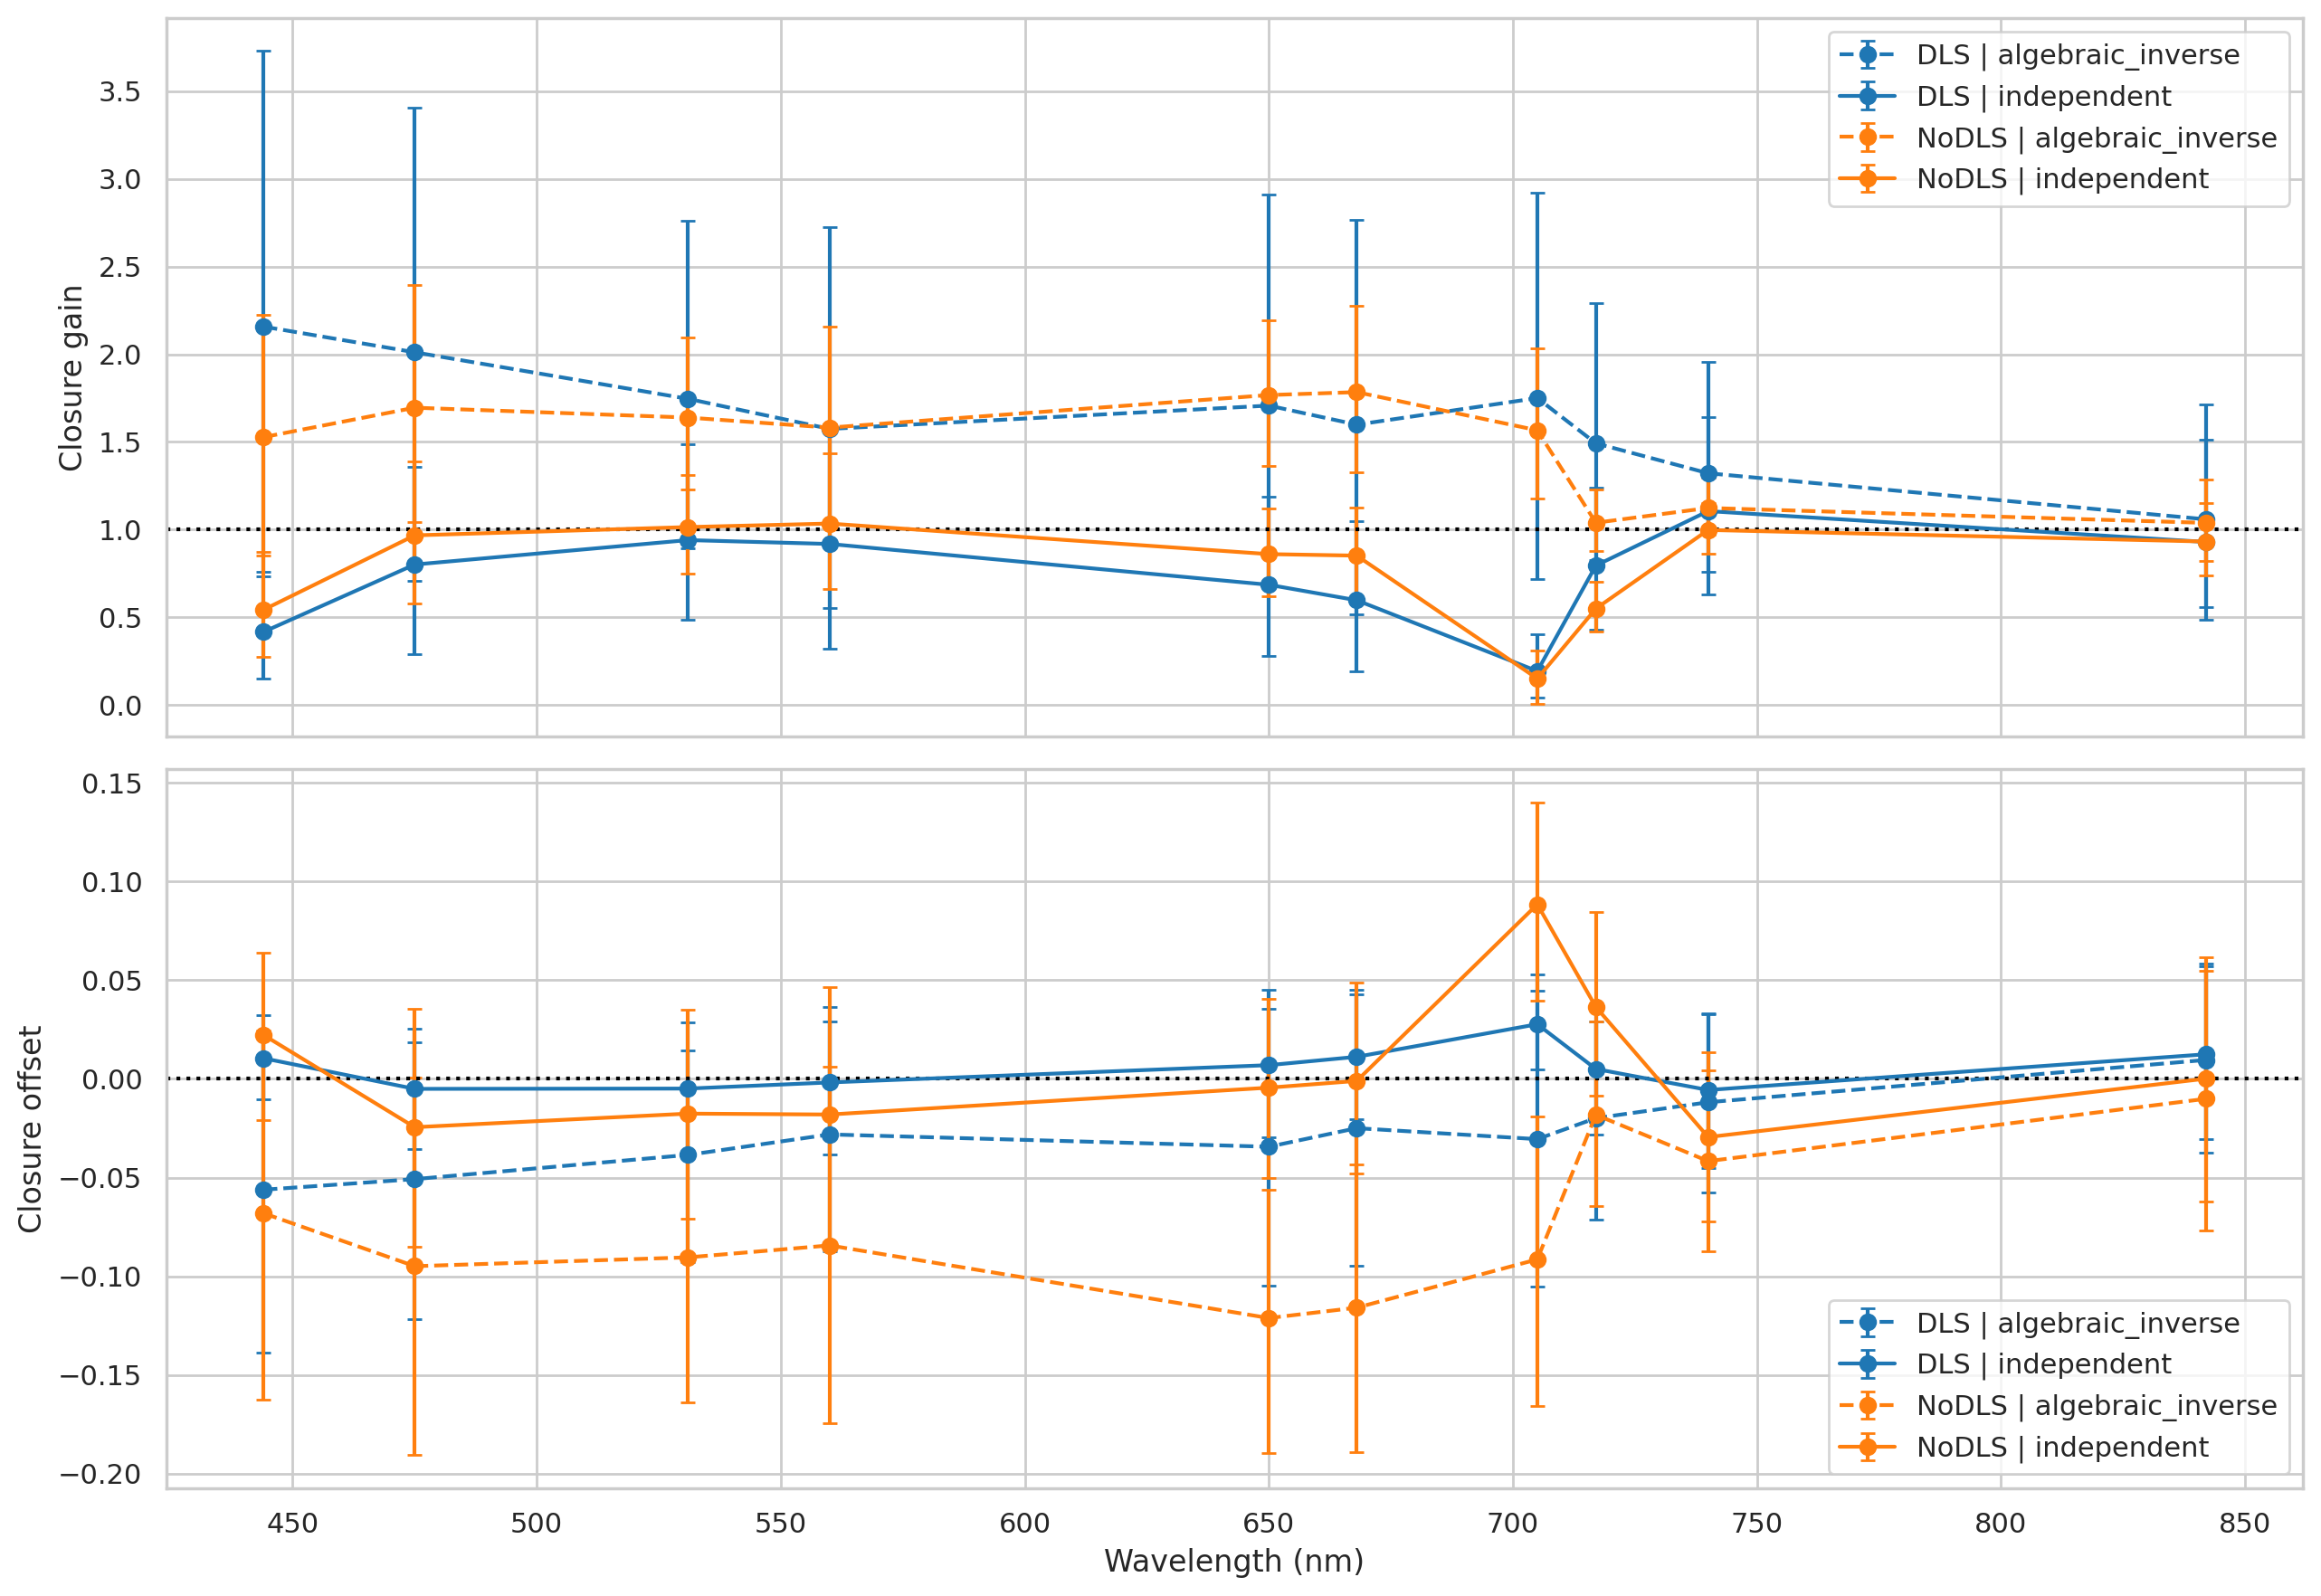

In [9]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True,
)

policy_styles = {
    "independent": "-",
    "algebraic_inverse": "--",
}

mode_colors = {
    "DLS": "tab:blue",
    "NoDLS": "tab:orange",
}

for (
    mode,
    policy,
), group in closure_summary.groupby(
    [
        "dls_mode",
        "spatial_reverse_policy",
    ],
    observed=True,
):
    group = group.loc[
        group["wavelength_nm"].notna()
    ].sort_values(
        "wavelength_nm"
    )

    label = f"{mode} | {policy}"

    axes[0].errorbar(
        group["wavelength_nm"],
        group["gain_mean"],
        yerr=[
            group["gain_mean"]
            - group["gain_ci_low"],
            group["gain_ci_high"]
            - group["gain_mean"],
        ],
        marker="o",
        capsize=3,
        color=mode_colors[mode],
        linestyle=policy_styles[
            policy
        ],
        label=label,
    )

    axes[1].errorbar(
        group["wavelength_nm"],
        group["offset_mean"],
        yerr=[
            group["offset_mean"]
            - group["offset_ci_low"],
            group["offset_ci_high"]
            - group["offset_mean"],
        ],
        marker="o",
        capsize=3,
        color=mode_colors[mode],
        linestyle=policy_styles[
            policy
        ],
        label=label,
    )

axes[0].axhline(
    1,
    color="black",
    linestyle=":",
)

axes[1].axhline(
    0,
    color="black",
    linestyle=":",
)

axes[0].set_ylabel(
    "Closure gain"
)
axes[1].set_ylabel(
    "Closure offset"
)
axes[1].set_xlabel(
    "Wavelength (nm)"
)

axes[0].legend()
axes[1].legend()

fig.tight_layout()
plt.show()

## 9. Empirical closure in the geographic overlap

In [10]:
empirical_closure_rows = []

for mode in DLS_MODES:
    patch_path = (
        SPATIAL_PATCH_DIR
        / (
            f"20260518_{mode}"
            "_homogeneous_overlap_patches.geojson"
        )
    )

    if not patch_path.exists():
        warnings.warn(
            f"Patch file not found: {patch_path}"
        )
        continue

    patches = gpd.read_file(
        patch_path
    )

    anchor = pd.DataFrame({
        band: patches[
            f"west_{band}_median"
        ]
        for band in SOURCE_BAND_NAMES
    })

    path_a = invert(
        TEMPORAL[
            ("westham", mode)
        ],
        f"path_a_{mode}",
    )

    spatial_may4_bw = spatial(
        "2026-05-04",
        mode,
        "brunswick_to_westham",
    )

    spatial_may18_bw = spatial(
        "2026-05-18",
        mode,
        "brunswick_to_westham",
    )

    spatial_may18_wb = spatial(
        "2026-05-18",
        mode,
        "westham_to_brunswick",
    )

    path_b_independent = compose(
        compose(
            spatial_may18_wb,
            invert(
                TEMPORAL[
                    ("brunswick", mode)
                ],
                f"b18_to_b4_{mode}",
            ),
            "w18_to_b4_independent",
        ),
        spatial_may4_bw,
        "path_b_independent",
    )

    path_b_reciprocal = compose(
        compose(
            invert(
                spatial_may18_bw,
                "w18_to_b18_reciprocal",
            ),
            invert(
                TEMPORAL[
                    ("brunswick", mode)
                ],
                f"b18_to_b4_{mode}",
            ),
            "w18_to_b4_reciprocal",
        ),
        spatial_may4_bw,
        "path_b_reciprocal",
    )

    values_a = apply_transform(
        anchor,
        path_a,
        SOURCE_BAND_NAMES,
    )

    for policy, path_b in [
        (
            "independent",
            path_b_independent,
        ),
        (
            "algebraic_inverse",
            path_b_reciprocal,
        ),
    ]:
        values_b = apply_transform(
            anchor,
            path_b,
            SOURCE_BAND_NAMES,
        )

        for band in SOURCE_BAND_NAMES:
            x = values_a[
                band
            ].to_numpy(float)

            y = values_b[
                band
            ].to_numpy(float)

            valid = (
                np.isfinite(x)
                & np.isfinite(y)
            )

            if valid.sum() < 3:
                continue

            model = (
                LinearRegression()
                .fit(
                    x[valid, None],
                    y[valid],
                )
            )

            predicted = model.predict(
                x[valid, None]
            )

            empirical_closure_rows.append({
                "dls_mode": mode,
                "spatial_reverse_policy": policy,
                "band_name": band,
                "wavelength_nm": (
                    SPECTRAL_WAVELENGTHS_NM
                    .get(band)
                ),
                "gain": float(
                    model.coef_[0]
                ),
                "offset": float(
                    model.intercept_
                ),
                "r2": float(
                    r2_score(
                        y[valid],
                        predicted,
                    )
                ),
                "rmse_between_paths": float(
                    np.sqrt(
                        np.mean(
                            (
                                y[valid]
                                - x[valid]
                            ) ** 2
                        )
                    )
                ),
                "mean_difference_path_b_minus_a":
                    float(
                        np.mean(
                            y[valid]
                            - x[valid]
                        )
                    ),
                "patch_count": int(
                    valid.sum()
                ),
            })


empirical_closure = pd.DataFrame(
    empirical_closure_rows
)

display(empirical_closure)

,dls_mode,spatial_reverse_policy,band_name,wavelength_nm,gain,offset,r2,rmse_between_paths,mean_difference_path_b_minus_a,patch_count
0,DLS,independent,B1,444.0,0.413118,0.010146,1.0,0.012607,-0.012474,500
1,DLS,independent,B2,475.0,0.794744,-0.005061,1.0,0.012919,-0.012890,500
2,DLS,independent,B3,531.0,0.926988,-0.004911,1.0,0.007996,-0.007981,500
3,DLS,independent,B4,560.0,0.902490,-0.001752,1.0,0.005762,-0.005704,500
4,DLS,independent,PAN,NaN,0.161876,0.025672,1.0,0.006538,-0.004493,500
5,DLS,independent,B5,650.0,0.671607,0.006825,1.0,0.006833,-0.006400,500
6,DLS,independent,B6,668.0,0.588851,0.010719,1.0,0.005093,-0.004225,500
7,DLS,independent,B7,705.0,0.190868,0.027263,1.0,0.006078,-0.003741,500
8,DLS,independent,B8,717.0,0.781063,0.004815,1.0,0.003453,-0.003167,500
9,DLS,independent,B9,740.0,1.090722,-0.005501,1.0,0.003041,-0.002878,500


## 10. Extract or load station pixels

In [11]:
def extraction_crs(source):
    if ASSUMED_RASTER_CRS is not None:
        return ASSUMED_RASTER_CRS

    if source.crs is None:
        raise ValueError(
            "Raster has no CRS."
        )

    return source.crs


def read_scaled(
    source,
    indexes,
    window=None,
):
    data = source.read(
        indexes=indexes,
        window=window,
        masked=True,
    )

    values = (
        np.ma.getdata(data)
        .astype(float)
    )

    mask = np.ma.getmaskarray(
        data
    )

    scales = (
        np.asarray(
            source.scales,
            dtype=float,
        )[
            np.asarray(indexes)
            - 1
        ]
    )

    offsets = (
        np.asarray(
            source.offsets,
            dtype=float,
        )[
            np.asarray(indexes)
            - 1
        ]
    )

    if (
        APPLY_NONDEFAULT_SCALE_OFFSET
        and (
            not np.allclose(
                scales,
                1,
            )
            or not np.allclose(
                offsets,
                0,
            )
        )
    ):
        values = (
            values
            * scales[:, None, None]
            + offsets[
                :, None, None
            ]
        )

    values[mask] = np.nan
    return values


def find_station_column(
    columns,
    candidates,
):
    lookup = {
        str(column).lower(): column
        for column in columns
    }

    return next(
        (
            lookup[candidate.lower()]
            for candidate in candidates
            if candidate.lower()
            in lookup
        ),
        None,
    )


def normalize_station_polygons(
    stations,
):
    result = stations.copy()

    station_column = find_station_column(
        result.columns,
        [
            "station_name",
            "station",
            "site_id",
            "plot",
            "name",
        ],
    )

    round_column = find_station_column(
        result.columns,
        [
            "round",
            "survey_round",
            "campaign_round",
        ],
    )

    quadrat_column = find_station_column(
        result.columns,
        [
            "is_3x3m",
            "is_3x3",
            "quadrat_3x3",
        ],
    )

    if station_column is None:
        raise KeyError(
            "Station-name column not found."
        )

    if round_column is None:
        raise KeyError(
            "Round column not found."
        )

    result["station_name"] = (
        result[station_column]
        .astype("string")
        .str.strip()
    )

    result["round"] = (
        pd.to_numeric(
            result[round_column],
            errors="raise",
        )
        .astype("Int64")
    )

    if quadrat_column is None:
        if USE_3X3M_QUADRATS:
            raise KeyError(
                "3x3 m quadrat flag was not found."
            )

        result["is_3x3m"] = False

    else:
        result["is_3x3m"] = (
            result[quadrat_column]
            .astype("string")
            .str.lower()
            .map({
                "true": True,
                "false": False,
                "yes": True,
                "no": False,
                "1": True,
                "0": False,
            })
            .astype("boolean")
        )

    result = result.loc[
        result["round"].isin(ROUNDS)
        & result["is_3x3m"].eq(
            USE_3X3M_QUADRATS
        )
    ].copy()

    result["site"] = np.where(
        result["station_name"]
        .str.startswith("W"),
        "westham",
        np.where(
            result["station_name"]
            .str.startswith("B"),
            "brunswick",
            None,
        ),
    )

    result = result.loc[
        result["site"].isin(SITES)
    ].copy()

    result["flight_date"] = (
        result["round"]
        .map(ROUND_DATES)
    )

    return result


def extract_pixels(
    raster_path,
    polygons,
    metadata,
):
    frames = []

    with rasterio.open(
        raster_path
    ) as source:
        if source.count != 11:
            raise ValueError(
                f"Expected 11 bands: "
                f"{raster_path}"
            )

        transformed = (
            polygons.to_crs(
                extraction_crs(source)
            )
        )

        for _, feature in transformed.iterrows():
            try:
                window = geometry_window(
                    source,
                    [
                        mapping(
                            feature.geometry
                        )
                    ],
                    boundless=False,
                )

            except rasterio.errors.WindowError:
                continue

            values = read_scaled(
                source,
                SOURCE_BAND_NUMBERS,
                window,
            )

            inside = geometry_mask(
                [
                    mapping(
                        feature.geometry
                    )
                ],
                out_shape=(
                    int(window.height),
                    int(window.width),
                ),
                transform=(
                    source.window_transform(
                        window
                    )
                ),
                invert=True,
                all_touched=ALL_TOUCHED,
            )

            valid = (
                inside
                & np.isfinite(
                    values
                ).all(axis=0)
            )

            local_rows, local_columns = (
                np.where(valid)
            )

            if len(local_rows) == 0:
                continue

            global_rows = (
                local_rows
                + int(window.row_off)
            )
            global_columns = (
                local_columns
                + int(window.col_off)
            )

            xs, ys = xy(
                source.transform,
                global_rows,
                global_columns,
                offset="center",
            )

            frame = pd.DataFrame(
                values[
                    :,
                    local_rows,
                    local_columns,
                ].T,
                columns=SOURCE_BAND_NAMES,
            )

            frame["station_name"] = (
                feature["station_name"]
            )

            frame["pixel_id"] = np.arange(
                len(frame)
            )

            frame["raster_row"] = (
                global_rows
            )
            frame["raster_col"] = (
                global_columns
            )
            frame["x"] = np.asarray(xs)
            frame["y"] = np.asarray(ys)

            for key, value in metadata.items():
                frame[key] = value

            frames.append(frame)

    if not frames:
        return pd.DataFrame()

    return pd.concat(
        frames,
        ignore_index=True,
    )


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if (
    REUSE_STATION_PIXEL_CACHE
    and not FORCE_STATION_REEXTRACTION
    and STATION_PIXEL_CACHE_PATH.exists()
):
    station_pixels_raw = pd.read_parquet(
        STATION_PIXEL_CACHE_PATH
    )

    print(
        "Loaded cached station pixels:",
        f"{len(station_pixels_raw):,}",
    )

else:
    station_polygons = (
        normalize_station_polygons(
            gpd.read_file(
                STATION_POLYGON_PATH
            )
        )
    )

    frames = []

    for date in ROUND_DATES.values():
        round_number = (
            DATE_TO_ROUND[date]
        )

        for site in SITES:
            polygons = station_polygons.loc[
                station_polygons["round"]
                .eq(round_number)
                & station_polygons["site"]
                .eq(site)
            ]

            for mode in DLS_MODES:
                print(
                    "Extracting:",
                    date,
                    site,
                    mode,
                )

                frame = extract_pixels(
                    RASTER_PATHS[
                        (
                            date,
                            site,
                            mode,
                        )
                    ],
                    polygons,
                    {
                        "flight_date": date,
                        "round": round_number,
                        "site": site,
                        "dls_mode": mode,
                    },
                )

                if frame.empty:
                    continue

                frame["highlight"] = (
                    frame["station_name"]
                    .isin(
                        STATIONS_TO_HIGHLIGHT
                        .get(
                            (
                                round_number,
                                site,
                            ),
                            [],
                        )
                    )
                )

                frames.append(frame)

    if not frames:
        raise RuntimeError(
            "No station pixels were extracted."
        )

    station_pixels_raw = pd.concat(
        frames,
        ignore_index=True,
    )

    station_pixels_raw.to_parquet(
        STATION_PIXEL_CACHE_PATH,
        index=False,
    )

    print(
        "Extracted station pixels:",
        f"{len(station_pixels_raw):,}",
    )

display(
    station_pixels_raw.head()
)

Extracting: 2026-05-04 westham DLS
Extracting: 2026-05-04 westham NoDLS
Extracting: 2026-05-04 brunswick DLS
Extracting: 2026-05-04 brunswick NoDLS
Extracting: 2026-05-18 westham DLS
Extracting: 2026-05-18 westham NoDLS
Extracting: 2026-05-18 brunswick DLS
Extracting: 2026-05-18 brunswick NoDLS
Extracted station pixels: 10,770


,B1,B2,B3,B4,PAN,B5,B6,B7,B8,B9,B10,station_name,pixel_id,raster_row,raster_col,x,y,flight_date,round,site,dls_mode,highlight
0,0.021723,0.023277,0.026793,0.029370,0.027487,0.030012,0.027419,0.031897,0.033002,0.033620,0.038683,W24,0,12318,13607,486637.996642,5.437189e+06,2026-05-04,1,westham,DLS,True
1,0.022006,0.023356,0.027705,0.029816,0.027779,0.030399,0.027767,0.031828,0.035441,0.035634,0.040127,W24,1,12318,13608,486638.296634,5.437189e+06,2026-05-04,1,westham,DLS,True
2,0.022271,0.023025,0.028515,0.029502,0.027524,0.031046,0.027525,0.032897,0.034791,0.035826,0.040678,W24,2,12318,13609,486638.596627,5.437189e+06,2026-05-04,1,westham,DLS,True
3,0.022006,0.022606,0.027898,0.028997,0.027081,0.030737,0.027191,0.033358,0.032625,0.033511,0.039200,W24,3,12318,13610,486638.896619,5.437189e+06,2026-05-04,1,westham,DLS,True
4,0.022121,0.022918,0.027694,0.028493,0.026950,0.030204,0.027081,0.033388,0.032219,0.033000,0.037553,W24,4,12318,13611,486639.196612,5.437189e+06,2026-05-04,1,westham,DLS,True


## 11. Apply correction routes and absolute-calibration options

In [12]:
def route_to_westham_may18(
    date,
    site,
    mode,
    route="preferred",
):
    if (
        date == "2026-05-18"
        and site == "westham"
    ):
        return identity()

    if (
        date == "2026-05-18"
        and site == "brunswick"
    ):
        return spatial(
            date,
            mode,
            "brunswick_to_westham",
        )

    if (
        date == "2026-05-04"
        and site == "westham"
    ):
        return TEMPORAL[
            (site, mode)
        ]

    if (
        date == "2026-05-04"
        and site == "brunswick"
    ):
        if route == "preferred":
            # Brunswick May 4 -> Brunswick May 18
            # -> Westham May 18.
            return compose(
                TEMPORAL[
                    ("brunswick", mode)
                ],
                spatial(
                    "2026-05-18",
                    mode,
                    "brunswick_to_westham",
                ),
                f"b4_b18_w18_{mode}",
            )

        if route == "alternate":
            # Brunswick May 4 -> Westham May 4
            # -> Westham May 18.
            return compose(
                spatial(
                    "2026-05-04",
                    mode,
                    "brunswick_to_westham",
                ),
                TEMPORAL[
                    ("westham", mode)
                ],
                f"b4_w4_w18_{mode}",
            )

    raise KeyError(
        (
            date,
            site,
            mode,
            route,
        )
    )


frames = []

for (
    date,
    site,
    mode,
), raw in station_pixels_raw.groupby(
    [
        "flight_date",
        "site",
        "dls_mode",
    ],
    observed=True,
):
    raw_stage = raw.copy()
    raw_stage["scope_stage"] = "raw"
    raw_stage["route"] = "raw"
    raw_stage["absolute_option"] = "none"

    frames.append(raw_stage)

    routes = (
        [
            "preferred",
            "alternate",
        ]
        if (
            date == "2026-05-04"
            and site == "brunswick"
        )
        else ["preferred"]
    )

    for route in routes:
        scoped = apply_transform(
            raw,
            route_to_westham_may18(
                date,
                site,
                mode,
                route,
            ),
            SOURCE_BAND_NAMES,
        )

        scoped["scope_stage"] = (
            "westham_may18_scope"
        )
        scoped["route"] = route
        scoped["absolute_option"] = "none"

        frames.append(
            scoped.copy()
        )

        for option in [
            "legacy",
            "recomputed",
        ]:
            try:
                absolute_table = absolute(
                    option,
                    mode,
                )

            except (
                FileNotFoundError,
                KeyError,
            ) as error:
                warnings.warn(
                    f"Skipping {option} "
                    f"| {mode}: {error}"
                )
                continue

            final = apply_transform(
                scoped,
                absolute_table,
                SPECTRAL_BAND_NAMES,
            )

            final["scope_stage"] = (
                "absolute"
            )
            final["route"] = route
            final[
                "absolute_option"
            ] = option

            frames.append(final)


station_pixels = pd.concat(
    frames,
    ignore_index=True,
)

denominator = (
    station_pixels[NIR_BAND_NAME]
    + station_pixels[RED_BAND_NAME]
)

station_pixels["ndvi740"] = (
    np.where(
        np.abs(denominator) > 1e-12,
        (
            station_pixels[
                NIR_BAND_NAME
            ]
            - station_pixels[
                RED_BAND_NAME
            ]
        )
        / denominator,
        np.nan,
    )
)

identifier_columns = [
    "flight_date",
    "round",
    "site",
    "dls_mode",
    "station_name",
    "highlight",
    "scope_stage",
    "route",
    "absolute_option",
]

spectra = (
    station_pixels.melt(
        id_vars=(
            identifier_columns
            + ["pixel_id"]
        ),
        value_vars=(
            SPECTRAL_BAND_NAMES
        ),
        var_name="band_name",
        value_name="reflectance",
    )
    .groupby(
        (
            identifier_columns
            + ["band_name"]
        ),
        observed=True,
    )["reflectance"]
    .agg(
        pixel_count="count",
        imagery_mean="mean",
        imagery_std="std",
        imagery_median="median",
    )
    .reset_index()
)

spectra["wavelength_nm"] = (
    spectra["band_name"]
    .map(
        SPECTRAL_WAVELENGTHS_NM
    )
)

ndvi = (
    station_pixels.groupby(
        identifier_columns,
        observed=True,
    )["ndvi740"]
    .agg(
        pixel_count="count",
        imagery_ndvi740_mean="mean",
        imagery_ndvi740_std="std",
    )
    .reset_index()
)

display(spectra.head())
display(ndvi.head())

/tmp/ipykernel_23076/3716018524.py:144: UserWarning: Skipping recomputed | DLS: Recomputed absolute coefficients are unavailable.
  warnings.warn(
/tmp/ipykernel_23076/3716018524.py:144: UserWarning: Skipping recomputed | DLS: Recomputed absolute coefficients are unavailable.
  warnings.warn(
/tmp/ipykernel_23076/3716018524.py:144: UserWarning: Skipping recomputed | NoDLS: Recomputed absolute coefficients are unavailable.
  warnings.warn(
/tmp/ipykernel_23076/3716018524.py:144: UserWarning: Skipping recomputed | NoDLS: Recomputed absolute coefficients are unavailable.
  warnings.warn(
/tmp/ipykernel_23076/3716018524.py:144: UserWarning: Skipping recomputed | DLS: Recomputed absolute coefficients are unavailable.
  warnings.warn(
/tmp/ipykernel_23076/3716018524.py:144: UserWarning: Skipping recomputed | NoDLS: Recomputed absolute coefficients are unavailable.
  warnings.warn(
/tmp/ipykernel_23076/3716018524.py:144: UserWarning: Skipping recomputed | DLS: Recomputed absolute coefficients

,flight_date,round,site,dls_mode,station_name,highlight,scope_stage,route,absolute_option,band_name,pixel_count,imagery_mean,imagery_std,imagery_median,wavelength_nm
0,2026-05-04,1,brunswick,DLS,B1,False,absolute,alternate,legacy,B1,36,0.005062,0.005534,0.004555,444
1,2026-05-04,1,brunswick,DLS,B1,False,absolute,alternate,legacy,B10,36,0.123219,0.003648,0.123011,842
2,2026-05-04,1,brunswick,DLS,B1,False,absolute,alternate,legacy,B2,36,0.035126,0.005087,0.034598,475
3,2026-05-04,1,brunswick,DLS,B1,False,absolute,alternate,legacy,B3,36,0.065409,0.004760,0.064934,531
4,2026-05-04,1,brunswick,DLS,B1,False,absolute,alternate,legacy,B4,36,0.092654,0.003838,0.092142,560


,flight_date,round,site,dls_mode,station_name,highlight,scope_stage,route,absolute_option,pixel_count,imagery_ndvi740_mean,imagery_ndvi740_std
0,2026-05-04,1,brunswick,DLS,B1,False,absolute,alternate,legacy,36,0.100787,0.014978
1,2026-05-04,1,brunswick,DLS,B1,False,absolute,preferred,legacy,36,0.039877,0.012218
2,2026-05-04,1,brunswick,DLS,B1,False,raw,raw,none,36,0.127887,0.011538
3,2026-05-04,1,brunswick,DLS,B1,False,westham_may18_scope,alternate,none,36,0.126013,0.011113
4,2026-05-04,1,brunswick,DLS,B1,False,westham_may18_scope,preferred,none,36,0.080438,0.008536


## 12. Load field spectra and calculate field NDVI740

In [13]:
def discover_ground_truth():
    candidates = []

    for root in GROUND_TRUTH_SEARCH_ROOTS:
        if not root.exists():
            continue

        for path in root.rglob("*"):
            if path.suffix.lower() not in {
                ".csv",
                ".parquet",
                ".pq",
            }:
                continue

            lower_name = path.name.lower()

            if (
                "ground" in lower_name
                or "field" in lower_name
                or "spectra" in lower_name
            ) and (
                "imagery_comparison"
                not in str(path).lower()
            ):
                candidates.append(path)

    return candidates


def find_column(
    columns,
    candidates,
):
    lookup = {
        str(column).lower(): column
        for column in columns
    }

    return next(
        (
            lookup[candidate.lower()]
            for candidate in candidates
            if candidate.lower()
            in lookup
        ),
        None,
    )


def normalize_ground(table):
    station_column = find_column(
        table.columns,
        [
            "station_name",
            "station",
            "site_id",
            "plot",
            "name",
        ],
    )

    round_column = find_column(
        table.columns,
        [
            "round",
            "survey_round",
            "campaign_round",
        ],
    )

    type_column = find_column(
        table.columns,
        [
            "sample_type",
            "type",
            "measurement_type",
        ],
    )

    wavelength_column = find_column(
        table.columns,
        [
            "wavelength_nm",
            "wavelength",
            "wl",
            "lambda_nm",
        ],
    )

    reflectance_column = find_column(
        table.columns,
        [
            "reflectance",
            "mean_reflectance",
            "value",
            "mean",
        ],
    )

    if None in (
        station_column,
        round_column,
        wavelength_column,
        reflectance_column,
    ):
        raise KeyError(
            "Ground-truth table is missing station, "
            "round, wavelength, or reflectance."
        )

    result = pd.DataFrame({
        "station_name": (
            table[station_column]
            .astype("string")
            .str.strip()
        ),
        "round": pd.to_numeric(
            table[round_column],
            errors="coerce",
        ),
        "wavelength_nm": pd.to_numeric(
            table[wavelength_column],
            errors="coerce",
        ),
        "field_reflectance": pd.to_numeric(
            table[reflectance_column],
            errors="coerce",
        ),
        "sample_type": (
            table[type_column]
            .astype("string")
            .str.strip()
            if type_column is not None
            else "R"
        ),
    }).dropna(
        subset=[
            "station_name",
            "round",
            "wavelength_nm",
            "field_reflectance",
        ]
    )

    return result.loc[
        result["sample_type"].eq("R")
    ]


if GROUND_TRUTH_TABLE is None:
    compatible = []

    for path in discover_ground_truth():
        try:
            candidate = normalize_ground(
                read_table(path)
            )
        except Exception:
            continue

        if (
            candidate["station_name"]
            .str.startswith(
                ("W", "B"),
                na=False,
            )
            .any()
            and candidate["round"]
            .isin(ROUNDS)
            .any()
        ):
            compatible.append(
                (path, candidate)
            )

    if len(compatible) != 1:
        raise RuntimeError(
            "Set GROUND_TRUTH_TABLE explicitly. "
            "Automatic discovery did not return "
            "exactly one compatible table. "
            f"Compatible count: {len(compatible)}"
        )

    ground_path, field = (
        compatible[0]
    )

else:
    ground_path = Path(
        GROUND_TRUTH_TABLE
    )

    field = normalize_ground(
        read_table(
            ground_path
        )
    )


print("Ground truth:", ground_path)

field_rows = []

for (
    station,
    round_number,
), group in field.groupby(
    [
        "station_name",
        "round",
    ],
    observed=True,
):
    group = group.sort_values(
        "wavelength_nm"
    )

    for (
        band,
        wavelength,
    ) in SPECTRAL_WAVELENGTHS_NM.items():
        field_rows.append({
            "station_name": station,
            "round": int(
                round_number
            ),
            "band_name": band,
            "wavelength_nm": wavelength,
            "field_reflectance": (
                np.interp(
                    wavelength,
                    group["wavelength_nm"],
                    group[
                        "field_reflectance"
                    ],
                )
            ),
        })


field_bands = pd.DataFrame(
    field_rows
)

field_wide = (
    field_bands.pivot_table(
        index=[
            "station_name",
            "round",
        ],
        columns="band_name",
        values="field_reflectance",
        aggfunc="mean",
    )
    .reset_index()
)

field_wide["field_ndvi740"] = (
    (
        field_wide[NIR_BAND_NAME]
        - field_wide[RED_BAND_NAME]
    )
    / (
        field_wide[NIR_BAND_NAME]
        + field_wide[RED_BAND_NAME]
    )
)

field_ndvi = field_wide[
    [
        "station_name",
        "round",
        "field_ndvi740",
    ]
]

RuntimeError: Set GROUND_TRUTH_TABLE explicitly. Automatic discovery did not return exactly one compatible table. Compatible count: 0

## 13. Ground-truth metrics

In [ ]:
spectra_comparison = spectra.merge(
    field_bands,
    on=[
        "station_name",
        "round",
        "band_name",
        "wavelength_nm",
    ],
    how="inner",
)

ndvi_comparison = ndvi.merge(
    field_ndvi,
    on=[
        "station_name",
        "round",
    ],
    how="inner",
)


def metrics(
    observed,
    predicted,
):
    observed = np.asarray(
        observed,
        dtype=float,
    )
    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    valid = (
        np.isfinite(observed)
        & np.isfinite(predicted)
    )

    observed = observed[valid]
    predicted = predicted[valid]

    if len(observed) < 2:
        return {
            "n": len(observed),
            "r2": np.nan,
            "rmse": np.nan,
            "mae": np.nan,
            "bias": np.nan,
            "nrmse_range": np.nan,
        }

    error = (
        predicted
        - observed
    )

    rmse = np.sqrt(
        np.mean(
            error ** 2
        )
    )

    observed_range = np.ptp(
        observed
    )

    return {
        "n": len(observed),
        "r2": r2_score(
            observed,
            predicted,
        ),
        "rmse": rmse,
        "mae": np.mean(
            np.abs(error)
        ),
        "bias": np.mean(error),
        "nrmse_range": (
            rmse / observed_range
            if observed_range
            else np.nan
        ),
    }


def grouped_metrics(
    data,
    observed,
    predicted,
    groups,
):
    output = []

    for key, group in data.groupby(
        groups,
        observed=True,
    ):
        if not isinstance(
            key,
            tuple,
        ):
            key = (key,)

        record = dict(
            zip(
                groups,
                key,
            )
        )

        record.update(
            metrics(
                group[observed],
                group[predicted],
            )
        )

        output.append(record)

    return pd.DataFrame(output)


spectral_metrics = grouped_metrics(
    spectra_comparison,
    "field_reflectance",
    "imagery_mean",
    [
        "round",
        "site",
        "dls_mode",
        "scope_stage",
        "route",
        "absolute_option",
        "band_name",
        "wavelength_nm",
    ],
)

spectral_overall = grouped_metrics(
    spectra_comparison,
    "field_reflectance",
    "imagery_mean",
    [
        "round",
        "site",
        "dls_mode",
        "scope_stage",
        "route",
        "absolute_option",
    ],
)

ndvi_metrics = grouped_metrics(
    ndvi_comparison,
    "field_ndvi740",
    "imagery_ndvi740_mean",
    [
        "round",
        "site",
        "dls_mode",
        "scope_stage",
        "route",
        "absolute_option",
    ],
)

display(
    spectral_overall.sort_values(
        ["rmse", "mae"]
    ).head(30)
)

display(
    ndvi_metrics.sort_values(
        ["rmse", "mae"]
    ).head(30)
)

## 14. Ground-truth comparison plots

In [ ]:
best_spectral_cases = (
    spectral_overall
    .sort_values(
        ["rmse", "mae"]
    )
    .head(12)[
        [
            "round",
            "site",
            "dls_mode",
            "scope_stage",
            "route",
            "absolute_option",
        ]
    ]
)

for case in best_spectral_cases.itertuples(
    index=False
):
    group = spectra_comparison.loc[
        spectra_comparison["round"]
        .eq(case.round)
        & spectra_comparison["site"]
        .eq(case.site)
        & spectra_comparison["dls_mode"]
        .eq(case.dls_mode)
        & spectra_comparison["scope_stage"]
        .eq(case.scope_stage)
        & spectra_comparison["route"]
        .eq(case.route)
        & spectra_comparison[
            "absolute_option"
        ].eq(case.absolute_option)
    ]

    if group.empty:
        continue

    figure, axis = plt.subplots(
        figsize=(7, 7)
    )

    normal = group.loc[
        ~group["highlight"]
    ]

    focus = group.loc[
        group["highlight"]
    ]

    axis.scatter(
        normal["field_reflectance"],
        normal["imagery_mean"],
        s=18,
        alpha=0.35,
        color="tab:blue",
        label="All other stations",
    )

    axis.scatter(
        focus["field_reflectance"],
        focus["imagery_mean"],
        s=48,
        alpha=0.9,
        facecolors="none",
        edgecolors="tab:red",
        linewidths=1.2,
        label="Highlighted stations",
    )

    values = np.r_[
        group[
            "field_reflectance"
        ].to_numpy(),
        group[
            "imagery_mean"
        ].to_numpy(),
    ]

    lower, upper = np.nanpercentile(
        values,
        [1, 99],
    )

    axis.plot(
        [lower, upper],
        [lower, upper],
        "k--",
        linewidth=1,
    )

    axis.set_xlim(
        lower,
        upper,
    )
    axis.set_ylim(
        lower,
        upper,
    )

    axis.set_xlabel(
        "Field reflectance"
    )
    axis.set_ylabel(
        "Imagery reflectance"
    )

    axis.set_title(
        f"R{case.round} "
        f"{case.site} "
        f"{case.dls_mode}\n"
        f"{case.scope_stage} | "
        f"{case.route} | "
        f"{case.absolute_option}"
    )

    axis.legend()
    figure.tight_layout()
    plt.show()

In [ ]:
figure, axis = plt.subplots(
    figsize=(8, 7)
)

for (
    option,
    group,
) in ndvi_comparison.groupby(
    "absolute_option",
    observed=True,
):
    axis.scatter(
        group["field_ndvi740"],
        group[
            "imagery_ndvi740_mean"
        ],
        s=22,
        alpha=0.45,
        label=option,
    )

values = np.r_[
    ndvi_comparison[
        "field_ndvi740"
    ].to_numpy(),
    ndvi_comparison[
        "imagery_ndvi740_mean"
    ].to_numpy(),
]

lower, upper = np.nanpercentile(
    values,
    [1, 99],
)

axis.plot(
    [lower, upper],
    [lower, upper],
    "k--",
    linewidth=1,
)

axis.set_xlabel(
    "Field NDVI740"
)
axis.set_ylabel(
    "Imagery NDVI740"
)
axis.set_title(
    "NDVI740 comparison across "
    "absolute-calibration options"
)
axis.legend()

figure.tight_layout()
plt.show()

## 15. Save outputs and coefficient provenance

In [ ]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    FIGURE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    chain_comparison.to_csv(
        OUTPUT_DIR
        / "chain_coefficient_comparison.csv",
        index=False,
    )

    closure_summary.to_csv(
        OUTPUT_DIR
        / "chain_closure_uncertainty.csv",
        index=False,
    )

    empirical_closure.to_csv(
        OUTPUT_DIR
        / "empirical_overlap_closure.csv",
        index=False,
    )

    closure_draws.to_parquet(
        OUTPUT_DIR
        / "chain_closure_draws.parquet",
        index=False,
    )

    station_pixels_raw.to_parquet(
        OUTPUT_DIR
        / "station_pixels_raw.parquet",
        index=False,
    )

    spectra.to_parquet(
        OUTPUT_DIR
        / "station_spectra_mean_std.parquet",
        index=False,
    )

    ndvi.to_parquet(
        OUTPUT_DIR
        / "station_ndvi740_mean_std.parquet",
        index=False,
    )

    spectra_comparison.to_parquet(
        OUTPUT_DIR
        / "imagery_vs_field_spectra.parquet",
        index=False,
    )

    ndvi_comparison.to_parquet(
        OUTPUT_DIR
        / "imagery_vs_field_ndvi740.parquet",
        index=False,
    )

    spectral_metrics.to_csv(
        OUTPUT_DIR
        / "spectral_metrics_by_band.csv",
        index=False,
    )

    spectral_overall.to_csv(
        OUTPUT_DIR
        / "spectral_metrics_overall.csv",
        index=False,
    )

    ndvi_metrics.to_csv(
        OUTPUT_DIR
        / "ndvi740_metrics.csv",
        index=False,
    )

    temporal_all.to_csv(
        OUTPUT_DIR
        / "loaded_temporal_coefficients.csv",
        index=False,
    )

    spatial_all.to_csv(
        OUTPUT_DIR
        / "loaded_bidirectional_spatial_coefficients.csv",
        index=False,
    )

    if not low_quality_spatial.empty:
        low_quality_spatial.to_csv(
            OUTPUT_DIR
            / "low_r2_spatial_coefficients.csv",
            index=False,
        )

    provenance = {
        "created_utc": datetime.now(
            timezone.utc
        ).isoformat(),
        "temporal_source_paths": sorted(
            temporal_all[
                "source_path"
            ].astype(str).unique()
        ),
        "spatial_coefficient_path": str(
            SPATIAL_COEFFICIENT_PATH
        ),
        "absolute_coefficient_path": str(
            ABSOLUTE_COEFFICIENT_PATH
        ),
        "minimum_spatial_r2_warning": (
            MIN_SPATIAL_R2_WARNING
        ),
        "strict_spatial_qa": (
            STRICT_SPATIAL_QA
        ),
        "closure_reverse_policies": [
            "independent",
            "algebraic_inverse",
        ],
        "coefficient_equation": (
            "destination = gain * source + offset"
        ),
    }

    with open(
        OUTPUT_DIR
        / "coefficient_provenance.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            provenance,
            file,
            indent=2,
        )

print("Outputs:", OUTPUT_DIR)

## Recommended review order

1. Inspect the loaded coefficient provenance and the low-\(R^2\) spatial table.
2. Compare independent-reverse and algebraic-inverse closure.
3. Review May 18 closure separately from May 4 because the independently fitted
   May 18 spatial relationship is weak in several bands.
4. Compare preferred and alternate Brunswick May 4 routes.
5. Compare raw, Westham-May-18 scope, and absolute-calibration stages.
6. Use RMSE, MAE, bias, and NDVI740 in addition to \(R^2\).
7. Retain all stations in output tables but emphasize the configured stations
   that should receive the greatest interpretation weight.